## Computer Vision - Aufgabe 2: Projektive Entzerrung

### Einlesen des Bildes

In [77]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data

image = plt.imread("schraegbild_tempelhof.jpg")
image = image.astype(float)
image = image / 255

# Test

### Bestimmung der Passpunkte: Ausgangskoordinaten _bi_ und Zielkoordinaten _oi_

In [78]:
# Ausgangskoordinaten
bi = np.array([
    [347, 326],
    [531, 324],
    [268, 547],
    [841, 524]
])

# Zielkoordinaten
oi = np.array([
    [0, 0],
    [400, 0], # [400, 200] # ==> non-rectangular, test
    [0, 600],
    [400, 600]
])

### Ermittlung der Kameraparameter _a_ für die projektive Entzerrung

In [79]:
def compute_rectification(oi, bi):
    A = []
    for i in range(4):
        x, y = bi[i]
        u, v = oi[i]
        A.append([x, y, 1, 0, 0, 0, -(u*x), -(u*y)])
        A.append([0, 0, 0, x, y, 1, -(v*x), -(v*y)])
    A = np.array(A)
    return  A

A = compute_rectification(oi, bi)
A_inverse = np.linalg.inv(A) # Pseudo-inverse not needed because only 4 points are used
x = oi
a_small = A_inverse @ x.flatten()


### Überprüfung der Transformation durch Anwendung auf Ausgangskoordinaten

In [83]:
transformed_points = []
for i in range(4):
    x = (a_small[0] * bi[i][0] + a_small[1] * bi[i][1] + a_small[2]) / (a_small[6] * bi[i][0] + a_small[7] * bi[i][1] + 1)
    y = (a_small[3] * bi[i][0] + a_small[4] * bi[i][1] + a_small[5]) / (a_small[6] * bi[i][0] + a_small[7] * bi[i][1] + 1)
    transformed_points.append([x, y])
print("transformed points:\n", transformed_points)
print("target points:\n", oi)

transformed points:
 [[np.float64(-3.943641023792122e-13), np.float64(5.258188031722829e-13)], [np.float64(399.99999999999966), np.float64(5.391489340076538e-13)], [np.float64(-1.2122816652452244e-13), np.float64(599.9999999999997)], [np.float64(399.99999999999983), np.float64(600.0000000000001)]]
target points:
 [[  0   0]
 [400   0]
 [  0 600]
 [400 600]]


### Anwendung der projektiven Entzerrung auf das Ausgangsbild

In [84]:
a1 = a_small[0]
a2 = a_small[1]
a3 = a_small[2]
b1 = a_small[3]
b2 = a_small[4]
b3 = a_small[5]
c1 = a_small[6]
c2 = a_small[7]

def image_rectification(image, out_h, out_w):
    rectified_image = np.zeros((out_h, out_w, 3), dtype=image.dtype)

    for i in range(out_h):
        for j in range(out_w):
            x_ref = j
            y_ref = i
            x = ((b2 - c2*b3)*x_ref + (a3*c2- a2)*y_ref + a2*b3 - a3*b2) / ((b1*c2 - b2*c1)*x_ref + (a2*c1 - a1*c2)*y_ref + a1*b2 - a2*b1)
            y = ((b3*c1 - b1)*x_ref + (a1 - a3*c1)*y_ref + a3*b1 - a1*b3) / ((b1*c2 - b2*c1)*x_ref + (a2*c1 - a1*c2)*y_ref + a1*b2 - a2*b1)
            x_n = int(np.round(x))
            y_n = int(np.round(y))
            if 0 <= x_n < image.shape[1] and 0 <= y_n < image.shape[0]:
                rectified_image[i, j] = image[y_n, x_n]
            else:
                rectified_image[i, j] = 0
    return rectified_image

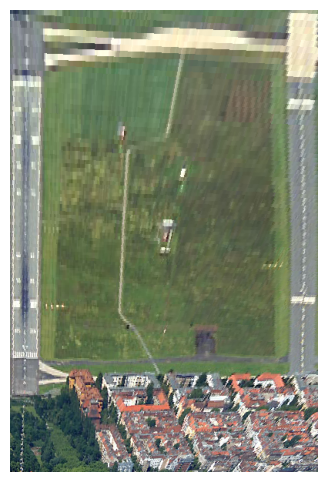

In [ ]:
# Calculate the L2-norm between the target points in case of non-rectangular format
# Question: Can it be non-rectangular?

out_w = int(max(
    np.linalg.norm(oi[0] - oi[1]),
    np.linalg.norm(oi[2] - oi[3])
))

out_h = int(max(
    np.linalg.norm(oi[0] - oi[2]),
    np.linalg.norm(oi[1] - oi[3])
))

rectified_image = image_rectification(image, out_h, out_w)
plt.figure(figsize=(8, 6))
plt.imshow(rectified_image)
plt.axis('off')
plt.show()